<a href="https://colab.research.google.com/github/LCCISNEROS/TALENTO-TECH/blob/main/experiencia/NLP_sobre_IMDB_Dataset_of_50K_Movie_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import keras

In [ ]:
#importing dataset
df=pd.read_csv('/content/IMDB Dataset.csv')
print (df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
#Checking Dataset Descriotion
print(df.describe())

                                                   review sentiment
count                                               50000     50000
unique                                              49582         2
top     Loved today's show!!! It was a variety and not...  positive
freq                                                    5     25000


In [ ]:
#sentiment count
print("Total : \n",df["sentiment"].value_counts())

Total : 
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
review = []
sentences = list(df["review"])
for sen in sentences:
    review.append(sen)

In [ ]:
labels = df["sentiment"]
labels = np.array(list(map(lambda x: 1 if x=="positive"else 0, labels)))

In [ ]:
from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20)

In [ ]:
from sklearn.model_selection import train_test_split
train_sentences, test_sentences, train_labels, test_labels = train_test_split(review, labels, test_size=0.20)

In [ ]:
# Parameters
vocab_size = 1000
max_length = 120
embedding_dim = 16
trunc_type="post"
oov_tok = "<OOV"

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Initialize the tokenizer class
Tokkenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok)
# generate the word index dictionary for the training sentences
Tokkenizer.fit_on_texts(train_sentences)
word_index = Tokkenizer.word_index
# Generate and pad the training sequences
sequences = Tokkenizer.texts_to_sequences(train_sentences)
padded = pad_sequences(sequences,maxlen=max_length, truncating=trunc_type)
# generate and pad the test sequences
test_sequences = Tokkenizer.texts_to_sequences(test_sentences)
testing_padded = pad_sequences(test_sequences,maxlen=max_length, truncating=trunc_type)

In [ ]:
import tensorflow as tf
from tensorflow import keras

# build the model
model = keras.Sequential([
    keras.layers.Embedding(vocab_size, embedding_dim),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
# Setup the training parameters
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6879 - loss: 0.5594 - val_accuracy: 0.7839 - val_loss: 0.4522
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8289 - loss: 0.3797 - val_accuracy: 0.7950 - val_loss: 0.4348
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8652 - loss: 0.3119 - val_accuracy: 0.7846 - val_loss: 0.4716
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9042 - loss: 0.2387 - val_accuracy: 0.7697 - val_loss: 0.5584
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9372 - loss: 0.1666 - val_accuracy: 0.7580 - val_loss: 0.6645
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9655 - loss: 0.1085 - val_accuracy: 0.7614 - val_loss: 0.8439
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9811 - loss: 0.0653 - val_accuracy: 0.7595 - val_loss: 1.0399
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9902 - loss: 0.03

<Axes: >

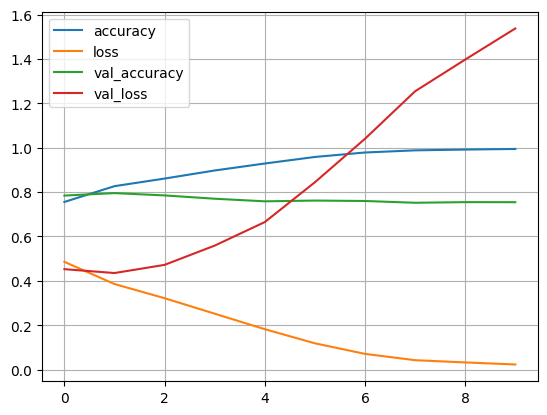

In [ ]:
# Train the model
history = model.fit(padded,
                    train_labels,
                    epochs=num_epochs,
                    validation_data=(testing_padded, test_labels))

# Graficar el historial de entrenamiento:
pd.DataFrame(history.history).plot(grid=True)